In [2]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
plt.style.use('ggplot')
#pd.set_option('display.max_columns', 1500)

In [3]:
df = pd.read_csv('../data/raw/Diffusion.csv')

In [59]:
diffusion_tool = df[df["Tool ID"] == 0].copy()

## Tool Parameters
Input 1 range: 1000-1400, aggression: 8
Input 2 range: 50-80, aggression: 3
Output range: 0.5-2

In [5]:
diffusion_tool.head(10)

,Tool Group,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output,Failed
1,Diffusion,0,3,544,1048,1045.256215,50.615071,0.512237,False
4,Diffusion,0,3,1118,1743,1085.942609,51.174957,0.528318,False
7,Diffusion,0,7,1743,2183,1124.326234,52.379653,0.557106,False
10,Diffusion,0,15,2210,2854,1157.032581,53.920023,0.598668,False
12,Diffusion,0,18,2854,3170,1203.249102,54.492069,0.639712,False
15,Diffusion,0,19,3170,3578,1218.997783,55.558611,0.676416,False
18,Diffusion,0,26,3578,4091,1271.304260,57.617705,0.780005,False
21,Diffusion,0,37,4091,4553,1286.702469,57.792861,0.800934,False
24,Diffusion,0,39,4553,4960,1286.767636,59.209515,0.847687,False
27,Diffusion,0,39,5026,5502,1329.276503,60.150956,0.932237,False


## Holistic View of Data

In [6]:
diffusion_tool.describe()

,Tool ID,LotID,Time In,Time Out,Input 1,Input 2,Output
count,3046.0,3046.000000,3.046000e+03,3.046000e+03,3046.000000,3046.000000,3046.000000
mean,0.0,7876.160867,7.878458e+05,7.883268e+05,1363.201040,59.896782,1.075637
std,0.0,4554.741670,4.552240e+05,4.552222e+05,207.973855,5.762471,0.483218
min,0.0,3.000000,5.440000e+02,1.048000e+03,995.780412,49.370756,0.498905
25%,0.0,3905.250000,3.922690e+05,3.926552e+05,1185.417874,54.996031,0.640884
50%,0.0,7924.500000,7.880440e+05,7.885760e+05,1358.831041,59.829250,0.948071
75%,0.0,11819.750000,1.182477e+06,1.182916e+06,1528.914146,64.511826,1.454160
max,0.0,15723.000000,1.576190e+06,1.576722e+06,1889.002772,76.673831,2.330773


The average of the inputs seem to be within the ranges of the tool.

## Univariate Distributions

Looking at Inputs first, ensuring monotonic drift:

Text(0, 0.5, 'Runs')

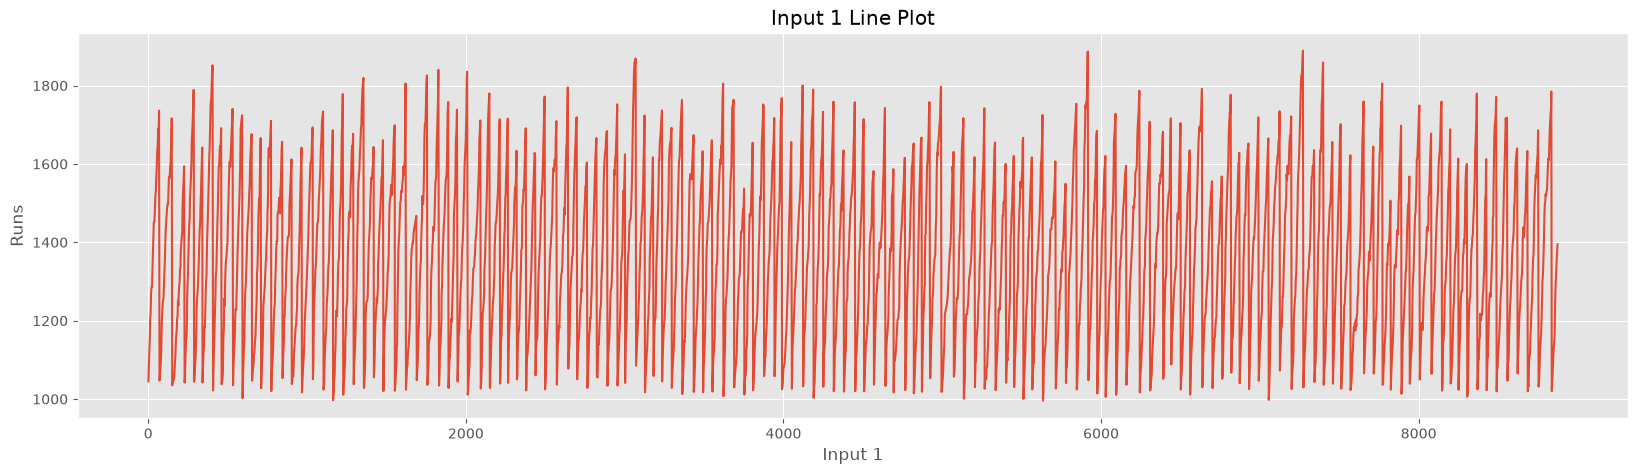

In [40]:
plt.figure(figsize=(20, 5))
line = diffusion_tool['Input 1'].plot(kind='line', title="Input 1 Line Plot")
line.set_xlabel('Input 1')
line.set_ylabel('Runs')

Text(0, 0.5, 'Runs')

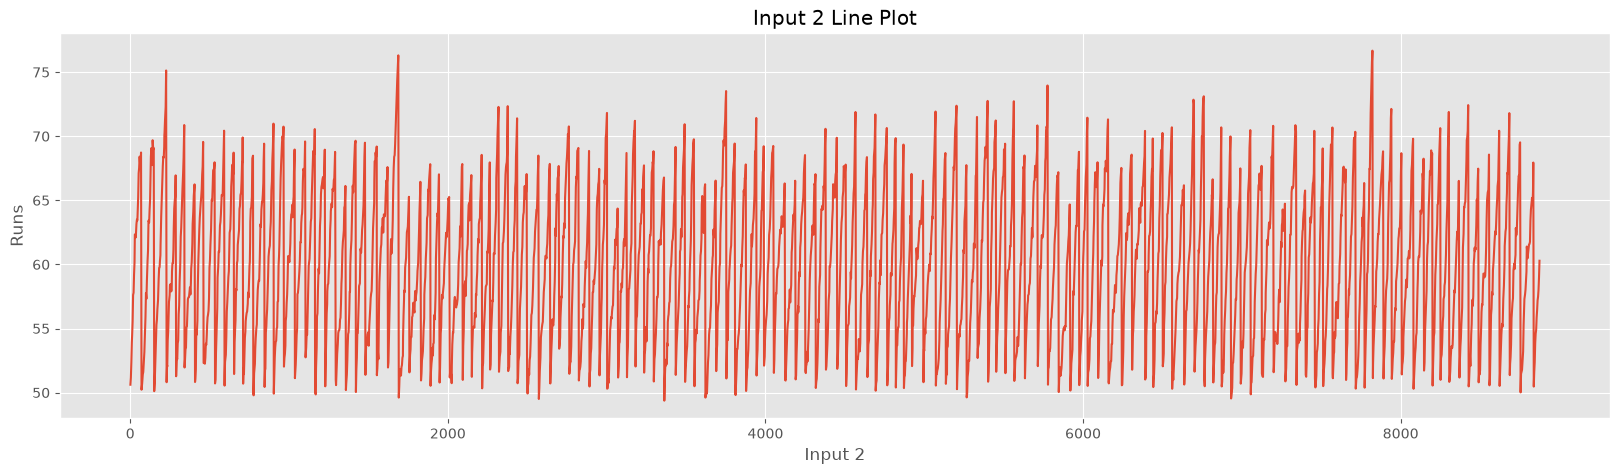

In [41]:
plt.figure(figsize=(20, 5))
line = diffusion_tool['Input 2'].plot(kind='line', title="Input 2 Line Plot")
line.set_xlabel('Input 2')
line.set_ylabel('Runs')

Both are showing what would be expected from degradation-driven inputs. Both show monotonic drift, although the noise in Input 2 seems to have a greater relative effect since Input 2 is much smaller in terms of magnitude.

Now an analysis of output

Text(0, 0.5, 'Runs')

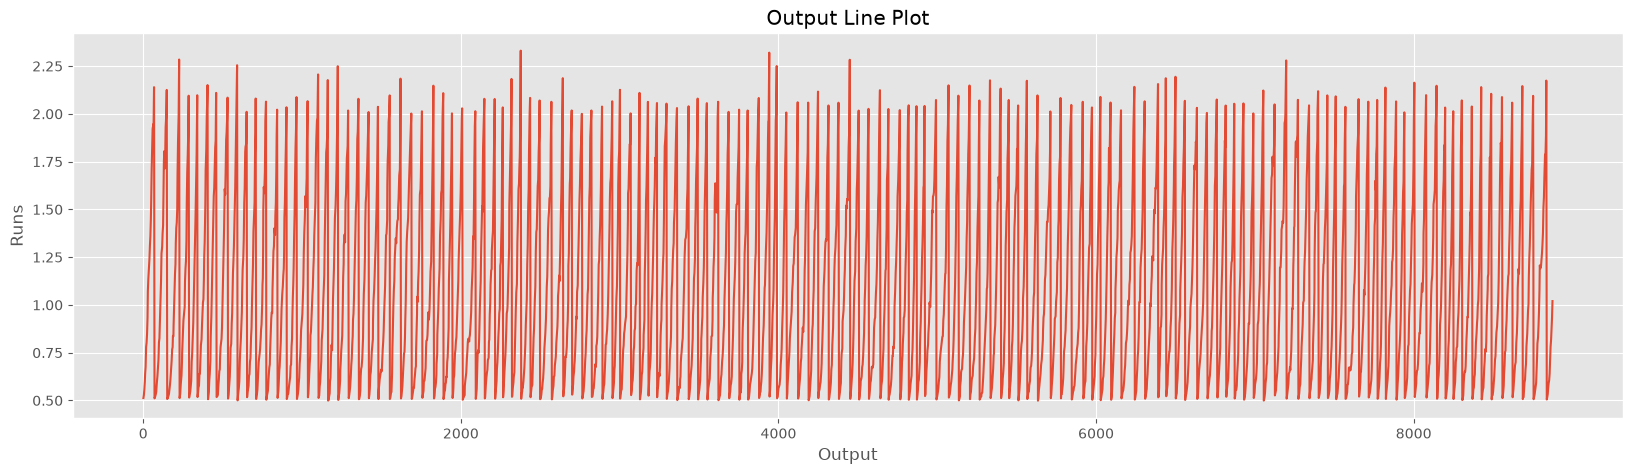

In [42]:
plt.figure(figsize=(20, 5))
line = diffusion_tool['Output'].plot(kind='line', title="Output Line Plot")
line.set_xlabel('Output')
line.set_ylabel('Runs')

All peaks have one data point before the output resets, and the output climbs as expected.

Visualising inputs and outputs together:

<Axes: >

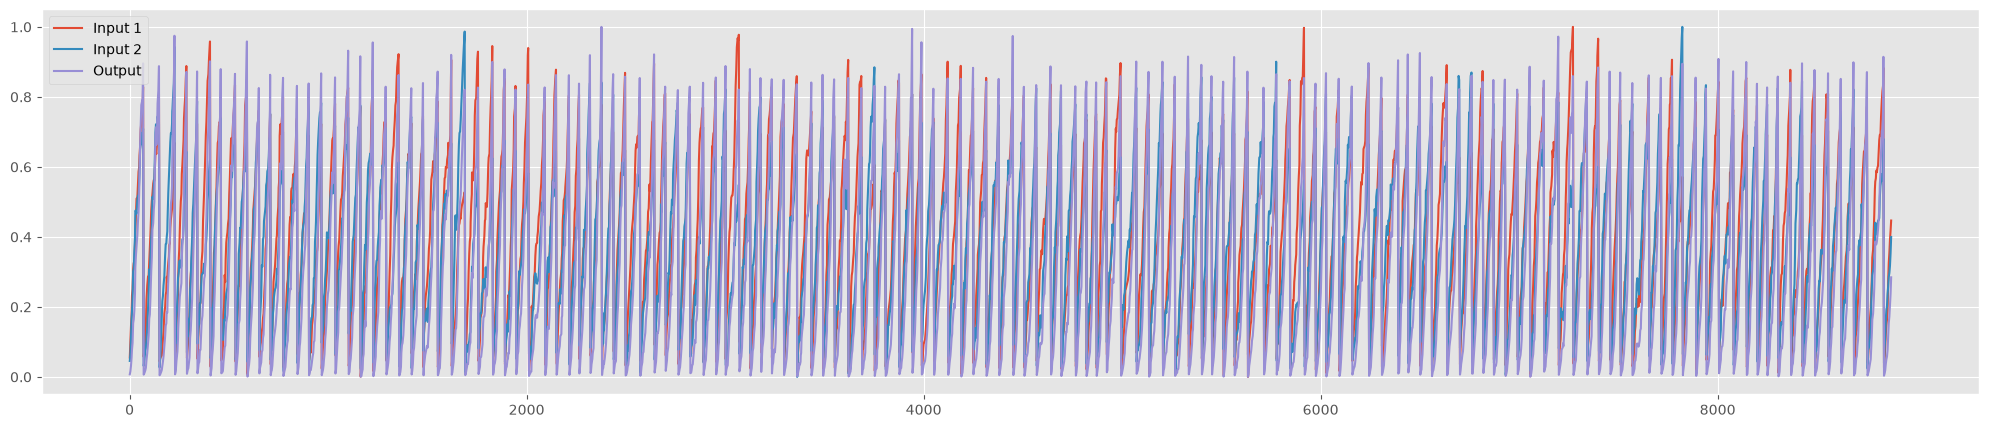

In [43]:
df_norm = (diffusion_tool[['Input 1', 'Input 2', 'Output']] - diffusion_tool[['Input 1', 'Input 2', 'Output']].min()) / \
          (diffusion_tool[['Input 1', 'Input 2', 'Output']].max() - diffusion_tool[['Input 1', 'Input 2', 'Output']].min())
df_norm.plot(kind='line',figsize=(25, 5))


Peaks and dips meet.


Looking into variable relationships:

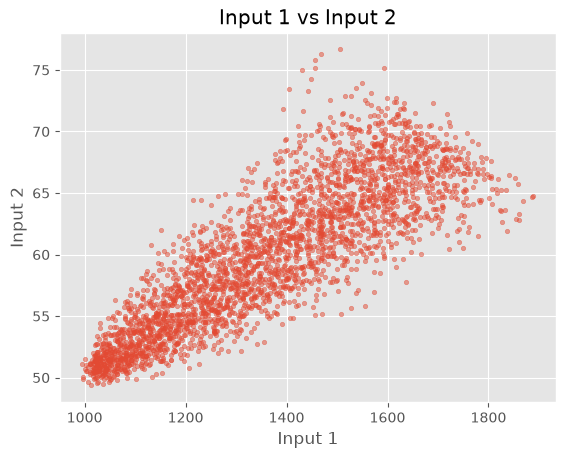

In [44]:
plt.scatter(diffusion_tool['Input 1'], diffusion_tool['Input 2'], alpha=0.5, s=10)
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('Input 1 vs Input 2')
plt.show()

Dense at lower values, as this is where the cycles reset to. As the inputs increase, there's a larger spread of values before a breach occurs, due to both drifting independently and together affecting the output.


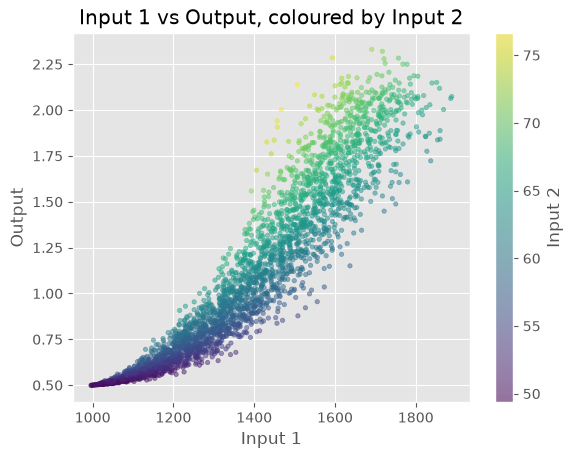

In [45]:
scatter = plt.scatter(diffusion_tool['Input 1'], diffusion_tool['Output'], c=diffusion_tool['Input 2'], alpha=0.5, s=10, cmap='viridis')
plt.xlabel('Input 1')
plt.ylabel('Output')
plt.colorbar(scatter, label='Input 2')
plt.title('Input 1 vs Output, coloured by Input 2')
plt.show()

Input 1 vs Input 2 shows a loose diagonal trend upwards. Both are independently randomised, but they're coupled through time since both reset together regardless of how they've changed over a cycle.

Input 1 vs Output (coloured by Input 2) shows a clear vertical band, where lower valuers correspond to a lower output and vice versa. Input 2 modulates on top of Input 1.

Output's dependence on Input 1 is not uniform across a cycle. Variance explained by Input 1 alone shrinks as the cycle progresses, consistent with the cxy interaction term growing with x. This suggests Input 2 (and their interaction) becomes increasingly important as a feature later in a cycle, which matters directly for RUL prediction near end-of-life. Furthermore, a simple linear regression model on raw Input 1 alone will likely underfit the curvature observed in the graph above, and so another model will likely need to be used.

This confirms that the formula used, output = kf(i1,i2) + c ,where f = i1 + i2^2 + 0.5(i1*i2), is outputting data as expected.

In [46]:
diffusion_tool[['Input 1', 'Input 2', 'Output']].corr()

,Input 1,Input 2,Output
Input 1,1.000000,0.851102,0.938425
Input 2,0.851102,1.000000,0.935649
Output,0.938425,0.935649,1.000000


In [60]:
diffusion_tool['Input 2'].pow(2).corr(diffusion_tool['Output'])

np.float64(0.9398674081663924)

As expected, Input 1 has a strong linear relationship with Output. Within the formula, Input 1 has a direct linear term in the formula used. Surprisingly, Input 2 also has a strong pairwise correlation (as input 2 is a non linear term in the equation),  potentially explained by Input 2 having a much narrower range, so its quadratic contribution does not have enough room to show its non-linearity. A look into the pearson correlation between Input 2 squared and output shows near enough the same value, confirming that the range is too narrow to see meaningful non-linear trends.

## Calculating RUL and observing individual variable effects on RUL

In [61]:
diffusion_tool["Shifted"] = diffusion_tool["Failed"].shift(periods=1, fill_value= False)
diffusion_tool["Cycle Group"] = diffusion_tool["Shifted"].cumsum()
diffusion_tool["Forward"] = diffusion_tool.groupby(["Cycle Group"]).cumcount()
diffusion_tool["Cycle Size"] = diffusion_tool.groupby("Cycle Group")["Failed"].transform("size")
diffusion_tool["RUL"] = diffusion_tool["Cycle Size"] - diffusion_tool["Forward"] - 1
diffusion_tool = diffusion_tool.drop(columns=['Shifted','Cycle Size','Forward'])


<Axes: xlabel='RUL', ylabel='Input 1'>

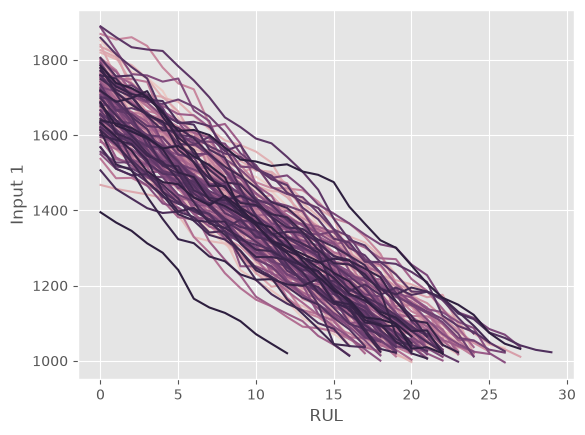

In [49]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Input 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Input 2'>

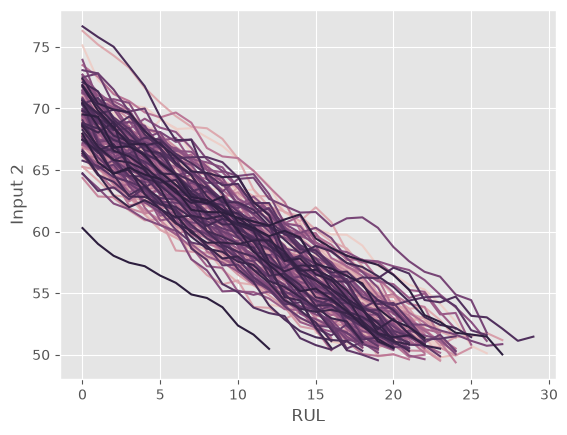

In [50]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Input 2", hue="Cycle Group", legend = False)

Comparing the inputs the RUL, we observe that each cycle follows a similar trend, and noise is lesser than when an exponential distribution was used for drift. At higher RUL values, the spread of values for the inputs are far smaller when compared to when we're approaching tool failure. This highlights the combination of the effect that the inputs have on the output, a cycle which had a lower input 2 needs a higher input 1 to breach. 

In [51]:
diffusion_tool["Rolling Mean 1"] = diffusion_tool.groupby("Cycle Group")["Input 1"].rolling(5).mean().reset_index(level=0,drop=True)
diffusion_tool["Rolling Mean 2"] = diffusion_tool.groupby("Cycle Group")["Input 2"].rolling(5).mean().reset_index(level=0,drop=True)


<Axes: xlabel='RUL', ylabel='Rolling Mean 1'>

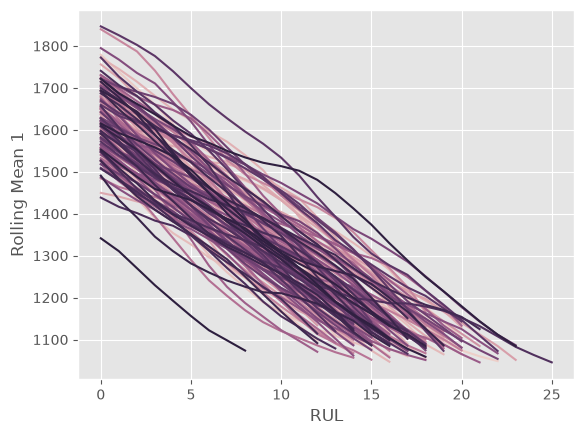

In [52]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Mean 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Mean 2'>

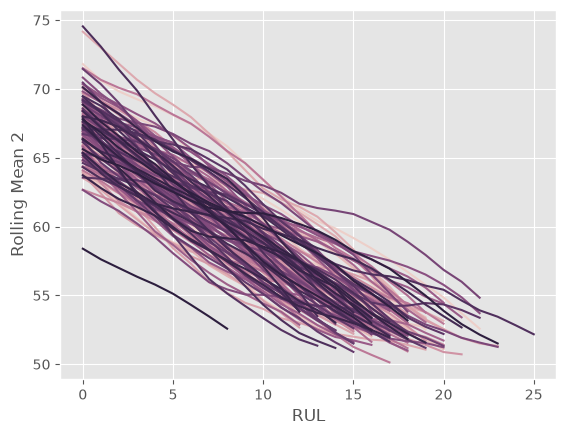

In [53]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Mean 2", hue="Cycle Group", legend = False)

Rolling means have smoothed out the cycles, but no major changes compared to raw values

<Axes: xlabel='RUL', ylabel='Rolling Std 1'>

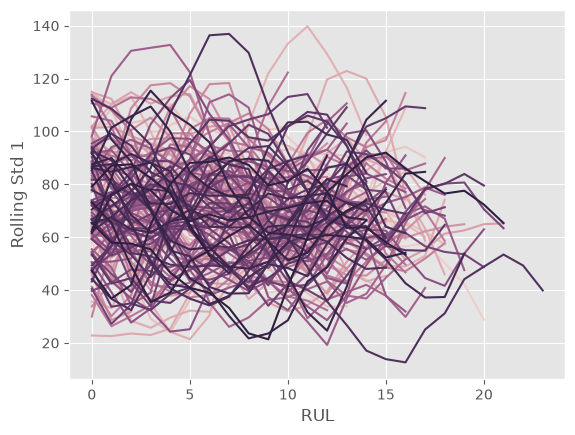

In [54]:
diffusion_tool["Rolling Std 1"] = diffusion_tool.groupby("Cycle Group")["Input 1"].rolling(7).std().reset_index(level=0,drop=True)
diffusion_tool["Rolling Std 2"] = diffusion_tool.groupby("Cycle Group")["Input 2"].rolling(7).std().reset_index(level=0,drop=True)
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Std 1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='Rolling Std 2'>

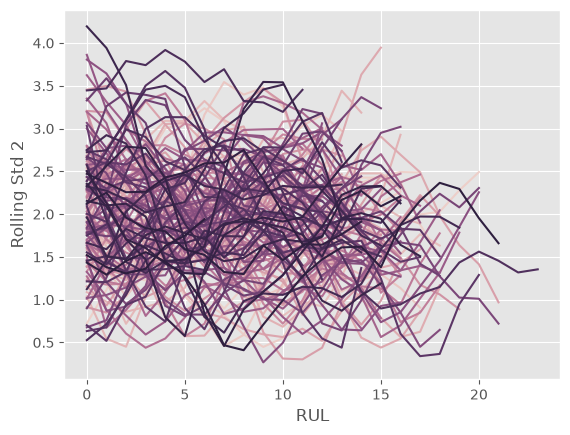

In [55]:
sns.lineplot(data=diffusion_tool, x="RUL", y="Rolling Std 2", hue="Cycle Group", legend = False)

In [56]:
n = 5
diffusion_tool["Shift1"] = diffusion_tool.groupby("Cycle Group")["Rolling Mean 1"].shift(n)
diffusion_tool["RoC1"] = diffusion_tool["Rolling Mean 1"] - diffusion_tool["Shift1"]

diffusion_tool["Shift2"] = diffusion_tool.groupby("Cycle Group")["Rolling Mean 2"].shift(n)
diffusion_tool["RoC2"] = diffusion_tool["Rolling Mean 2"] - diffusion_tool["Shift2"]

<Axes: xlabel='RUL', ylabel='RoC1'>

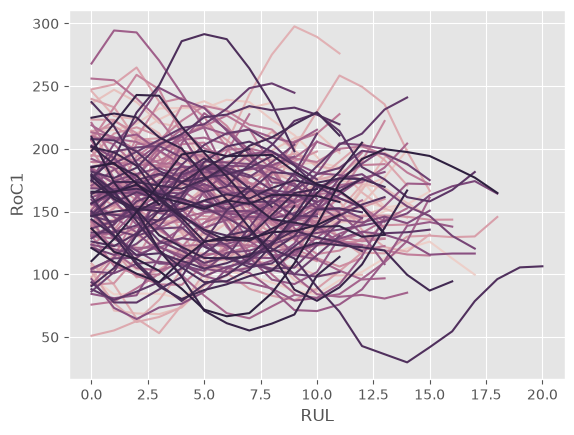

In [57]:
sns.lineplot(data=diffusion_tool, x="RUL", y="RoC1", hue="Cycle Group", legend = False)

<Axes: xlabel='RUL', ylabel='RoC2'>

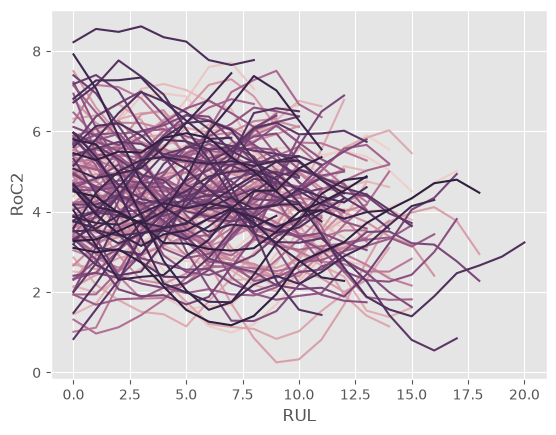

In [58]:
sns.lineplot(data=diffusion_tool, x="RUL", y="RoC2", hue="Cycle Group", legend = False)

Drift is drawn from a gamma distribution and noise from a normal distribution, and both are drawn independently at every step. Successive draws are therefore independent and identically distributed (approximately for noise, whose scale is proportional to the current reading and so shifts as the reading grows).

Gamma is not memoryless, unlike the exponential distribution originally used. However, that property describes the internal structure of a single draw's waiting time and never comes into play here, since a fresh independent draw is taken each step and no state carries over. Gamma was chosen purely to reduce the coefficient of variation from 1.0 to 0.5, which produces more consistent wear rates and tighter cycle lengths, and to move the mode away from zero so that near-zero degradation steps become rare rather than the most likely outcome.

This EDA shows that no single feature resolves RUL on its own, and that the spread widens as the tool approaches failure. This is expected: breach is triggered by Output, which depends on both inputs jointly, so at the moment of breach it is the combination of Input 1 and Input 2 that is constrained, leaving either input alone free to vary. A cycle in which Input 2 ran low requires a higher Input 1 to breach, and vice versa.

Rolling standard deviation and rate of change were both tested and excluded. Both attempt to read a quantity that is redrawn independently at every step rather than one that accumulates, so neither can encode how far through a cycle the tool is. Rolling mean survives because level is a cumulative sum of past draws, which is genuine state.

The relationship between inputs and Output is nonlinear and contains an interaction term, so a linear model on these features would underfit regardless of how they are engineered. The next step is multivariate nonlinear regression using a tree-based model, which can learn a joint function of the features without the functional form being specified in advance.

Note that the interaction between the two inputs was deliberately not hand-engineered as a feature. Although the generating formula is known here, it would not be known for a real tool, so encoding it would rely on information unavailable in deployment. The model is instead expected to discover the interaction from the features supplied, which can be verified afterwards using feature importance and SHAP. 